In [1]:
# Imports
from pathlib import Path
import io
import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
import urllib.request
import zstandard as zstd
import chess
import chess.pgn
import chess.engine

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  median_absolute_error,
  r2_score,
)

from xgboost import XGBRegressor
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
# Configuration
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = DATA_DIR / "models"

for path in [RAW_DIR, PROCESSED_DIR, MODEL_DIR]:
  path.mkdir(parents=True, exist_ok=True)

# Lichess monthly database file.
year = 2017
month = 5

filename = f"lichess_db_standard_rated_{year}-{month:02d}.pgn.zst"
url = f"https://database.lichess.org/standard/{filename}"
zst_path = RAW_DIR / filename

# Keep this modest. PGN parsing is cheap; Stockfish analysis is not.
MAX_GAMES_TO_READ = 50_000
N_GAMES_ENGINE = 10_000

# Analyze only the first N plies of each game. 30 plies = 15 full moves.
# Increasing this improves signal but scales linearly in runtime.
# ENGINE_MAX_PLIES = 30
# ENGINE_DEPTH = 8
# ENGINE_THREADS = 1
# ENGINE_HASH_MB = 128

# Cap extreme mate-conversion losses so one forced mate does not dominate.
# CP_LOSS_CLIP = 2_000
# MATE_SCORE = 100_000

# Change this manually if shutil.which("stockfish") does not find your binary.
STOCKFISH_PATH = os.environ.get("STOCKFISH_PATH") or shutil.which("stockfish")

print("PGN URL:", url)
print("Local path:", zst_path)
print("Stockfish path:", STOCKFISH_PATH)

PGN URL: https://database.lichess.org/standard/lichess_db_standard_rated_2017-05.pgn.zst
Local path: data/raw/lichess_db_standard_rated_2017-05.pgn.zst
Stockfish path: /opt/homebrew/bin/stockfish


In [3]:
# Download PGN file
if not zst_path.exists():
  print(f"Downloading {filename}...")
  urllib.request.urlretrieve(url, zst_path)
  print("Done.")
else:
  print("File already exists.")

File already exists.


In [4]:
# PGN streaming helpers
def iter_pgn_games_from_zst(zst_path, max_games=None):
  """Yield python-chess Game objects from a compressed Lichess PGN file."""
  dctx = zstd.ZstdDecompressor()

  with open(zst_path, "rb") as compressed:
    with dctx.stream_reader(compressed) as reader:
      text_stream = io.TextIOWrapper(reader, encoding="utf-8")

      n_games = 0
      while True:
        game = chess.pgn.read_game(text_stream)

        if game is None:
          break

        yield game
        n_games += 1

        if max_games is not None and n_games >= max_games:
          break


def parse_rating(value):
  """Parse Lichess rating headers, keeping provisional '?' information separate."""
  if value is None:
    return np.nan, False

  text = str(value).strip()
  is_provisional = text.endswith("?")
  text = text.replace("?", "")

  try:
    return float(text), is_provisional
  except ValueError:
    return np.nan, is_provisional


def game_to_light_record(game):
  """Extract metadata plus SAN/UCI moves without doing engine analysis yet."""
  headers = game.headers
  board = game.board()

  moves_san = []
  moves_uci = []

  for move in game.mainline_moves():
    moves_san.append(board.san(move))
    moves_uci.append(move.uci())
    board.push(move)

  white_elo, white_provisional = parse_rating(headers.get("WhiteElo"))
  black_elo, black_provisional = parse_rating(headers.get("BlackElo"))

  return {
    "event": headers.get("Event"),
    "site": headers.get("Site"),
    "date": headers.get("UTCDate", headers.get("Date")),
    "time": headers.get("UTCTime"),
    "white": headers.get("White"),
    "black": headers.get("Black"),
    "result": headers.get("Result"),
    "white_elo": white_elo,
    "black_elo": black_elo,
    "white_provisional": white_provisional,
    "black_provisional": black_provisional,
    "white_rating_diff": headers.get("WhiteRatingDiff"),
    "black_rating_diff": headers.get("BlackRatingDiff"),
    "eco": headers.get("ECO"),
    "opening": headers.get("Opening"),
    "time_control": headers.get("TimeControl"),
    "termination": headers.get("Termination"),
    "num_plies": len(moves_uci),
    "num_full_moves": len(moves_uci) / 2,
    "moves_san": " ".join(moves_san),
    "moves_uci": " ".join(moves_uci),
  }

In [5]:
metadata_path = PROCESSED_DIR / (
  f"lichess_{year}_{month:02d}_metadata_first_{MAX_GAMES_TO_READ}.parquet"
)

if metadata_path.exists():
  df_raw = pd.read_parquet(metadata_path)
  print(f"Loaded cached metadata: {metadata_path}")
else:
  records = []
  game_iter = iter_pgn_games_from_zst(
    zst_path,
    max_games=MAX_GAMES_TO_READ,
  )

  for game in tqdm(game_iter, total=MAX_GAMES_TO_READ):
    records.append(game_to_light_record(game))

  df_raw = pd.DataFrame(records)
  df_raw.to_parquet(metadata_path, index=False)
  print(f"Wrote: {metadata_path}")

df_raw.head()

Loaded cached metadata: data/processed/lichess_2017_05_metadata_first_50000.parquet


,event,site,date,time,white,black,result,white_elo,black_elo,white_provisional,black_provisional,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san,moves_uci
0,Rated Bullet game,https://lichess.org/ObT3MGJ6,2017.04.30,22:00:00,marshall91,Nechemevich,0-1,1926.0,1969.0,False,False,-10,+9,B01,Scandinavian Defense: Modern Variation #2,60+0,Time forfeit,92,46.0,e4 d5 exd5 Nf6 d3 Qxd5 Nc3 Qf5 Be2 Bd7 g4 Qe6 ...,e2e4 d7d5 e4d5 g8f6 d2d3 d8d5 b1c3 d5f5 f1e2 c...
1,Rated Bullet game,https://lichess.org/wcL9cyTi,2017.04.30,22:00:00,LTKAUNAS,Paupara,1-0,1592.0,1427.0,False,False,+6,-6,A00,Mieses Opening,60+0,Time forfeit,79,39.5,d3 e6 e3 d5 Nf3 Nf6 Be2 Be7 O-O O-O Nc3 Nbd7 N...,d2d3 e7e6 e2e3 d7d5 g1f3 g8f6 f1e2 f8e7 e1g1 e...
2,Rated Bullet game,https://lichess.org/D32us0RF,2017.04.30,22:00:00,ateoluz,yigitmustafa,1-0,1247.0,1174.0,False,False,+9,-9,D00,Blackmar-Diemer Gambit,60+0,Time forfeit,45,22.5,d4 d5 e4 dxe4 c4 Nf6 Qc2 Bf5 Nc3 Qxd4 Be3 Qe5 ...,d2d4 d7d5 e2e4 d5e4 c2c4 g8f6 d1c2 c8f5 b1c3 d...
3,Rated Bullet game,https://lichess.org/6RBz5epC,2017.04.30,22:00:00,le_batman,aleksandra_91,1-0,2047.0,2009.0,False,False,+8,-9,A00,Van't Kruijs Opening,60+0,Time forfeit,95,47.5,e3 c5 d3 d5 Nf3 Nc6 Be2 Nf6 O-O g6 h3 Bg7 Re1 ...,e2e3 c7c5 d2d3 d7d5 g1f3 b8c6 f1e2 g8f6 e1g1 g...
4,Rated Blitz game,https://lichess.org/z2b2Y95l,2017.04.30,22:00:00,Trollson,salahi2,1-0,1767.0,1781.0,False,False,+10,-11,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,Time forfeit,75,37.5,e4 d5 exd5 Qxd5 Nc3 Qd8 d4 Bf5 Nf3 e6 Nh4 Bg6 ...,e2e4 d7d5 e4d5 d8d5 b1c3 d5d8 d2d4 c8f5 g1f3 e...


In [6]:
print(df_raw.shape)
df_raw.info()

(50000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event              50000 non-null  str    
 1   site               50000 non-null  str    
 2   date               50000 non-null  str    
 3   time               50000 non-null  str    
 4   white              50000 non-null  str    
 5   black              50000 non-null  str    
 6   result             50000 non-null  str    
 7   white_elo          50000 non-null  float64
 8   black_elo          50000 non-null  float64
 9   white_provisional  50000 non-null  bool   
 10  black_provisional  50000 non-null  bool   
 11  white_rating_diff  49977 non-null  str    
 12  black_rating_diff  49977 non-null  str    
 13  eco                50000 non-null  str    
 14  opening            50000 non-null  str    
 15  time_control       50000 non-null  str    
 16  termination        50

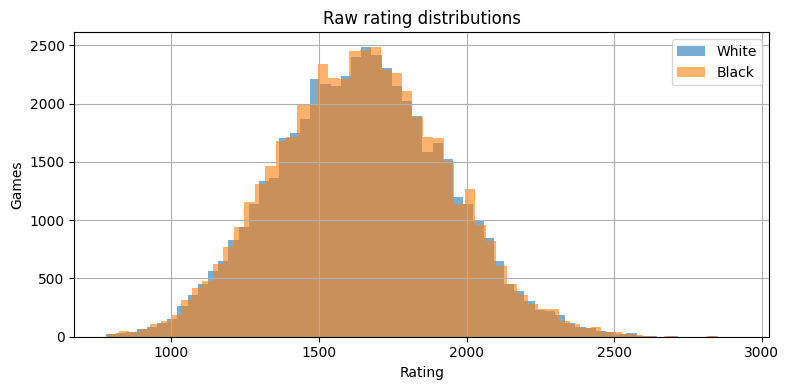

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_raw["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Raw rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

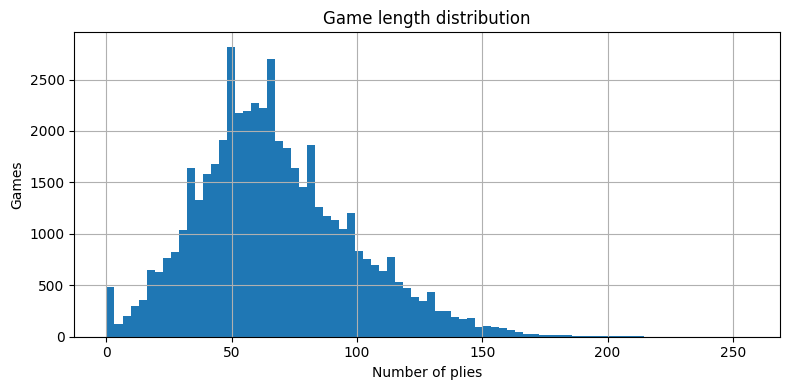

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["num_plies"].hist(bins=80, ax=ax)
ax.set_xlabel("Number of plies")
ax.set_ylabel("Games")
ax.set_title("Game length distribution")
plt.tight_layout()
plt.show()

In [9]:
print("Results:")
display(df_raw["result"].value_counts(dropna=False).to_frame("count"))

print("\nTermination:")
display(df_raw["termination"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nTime controls:")
display(df_raw["time_control"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nOpenings:")
display(df_raw["opening"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nTime:")
display(df_raw["time"].value_counts(dropna=False).head(20).to_frame("count"))


print("\nEvents:")
display(df_raw["event"].value_counts(dropna=False).head(20).to_frame("count"))

Results:


,count
result,
1-0,24765
0-1,23331
1/2-1/2,1896
*,8



Termination:


,count
termination,
Normal,32906
Time forfeit,16849
Abandoned,234
Unterminated,6
Rules infraction,5



Time controls:


...

,count
opening,
Van't Kruijs Opening,958
Scandinavian Defense: Mieses-Kotroc Variation,910
Modern Defense,774
Sicilian Defense,685
Scandinavian Defense,673
Horwitz Defense,652
French Defense: Knight Variation,650
Owen Defense,613
Caro-Kann Defense,608



Time:


,count
time,
22:00:01,84
00:00:02,66
23:00:03,56
01:00:02,44
22:27:07,33
22:36:38,29
22:55:44,29
22:24:52,26
22:55:30,26



Events:


,count
event,
Rated Blitz game,19505
Rated Classical game,10704
Rated Bullet game,10650
Rated Classical tournament https://lichess.org/tournament/Ajk1flnF,535
Rated UltraBullet game,496
Rated Blitz tournament https://lichess.org/tournament/3xxzNmSV,474
Rated Bullet tournament https://lichess.org/tournament/QrSb3mjZ,463
Rated Blitz tournament https://lichess.org/tournament/lMB6mMlI,421
Rated Blitz tournament https://lichess.org/tournament/ty447zFJ,417


In [10]:
# Filter out data 
MIN_PLIES = 20
REMOVE_EXACT_1500 = False
REMOVE_PROVISIONAL = True
BLITZ_ONLY = True

valid_mask = (
  df_raw["white_elo"].notna()
  & df_raw["black_elo"].notna()
  & df_raw["result"].isin(["1-0", "0-1", "1/2-1/2"])
  & df_raw["moves_uci"].notna()
  & df_raw["num_plies"].ge(MIN_PLIES)
)

if REMOVE_EXACT_1500:
  valid_mask &= ~(
    df_raw["white_elo"].eq(1500)
    | df_raw["black_elo"].eq(1500)
  )

if REMOVE_PROVISIONAL:
  valid_mask &= ~(
    df_raw["white_provisional"].fillna(False)
    | df_raw["black_provisional"].fillna(False)
  )

if BLITZ_ONLY:
  valid_mask &= (
    df_raw["event"].eq("Rated Blitz game")
  )

df_games = df_raw.loc[valid_mask].copy()

print("Rows before filtering:", len(df_raw))
print("Rows after filtering: ", len(df_games))
print("Removed:              ", len(df_raw) - len(df_games))

df_games[["white_elo", "black_elo", "num_plies"]].describe()

Rows before filtering: 50000
Rows after filtering:  18855
Removed:               31145


,white_elo,black_elo,num_plies
count,18855.000000,18855.000000,18855.000000
mean,1634.362079,1633.201485,71.149722
std,288.171204,288.704094,30.596650
min,778.000000,789.000000,20.000000
25%,1434.000000,1432.000000,49.000000
50%,1639.000000,1638.000000,66.000000
75%,1833.000000,1833.000000,90.000000
max,2594.000000,2591.000000,254.000000


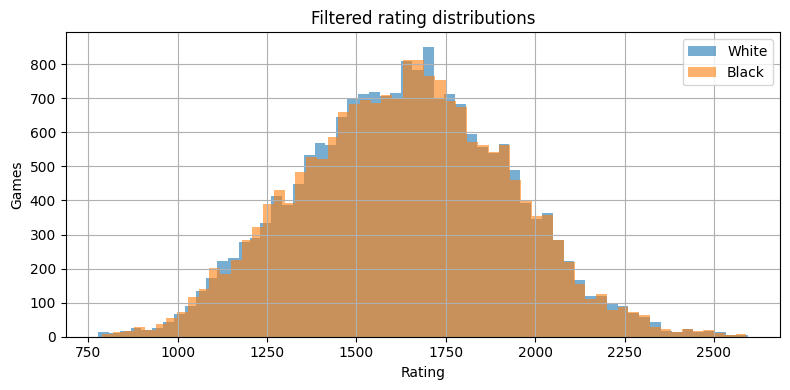

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
df_games["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_games["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Filtered rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

## First investigation. Separate bottom from top, classification problem

Part A. Features alone.
Part B. Stockfish. 

In [42]:
from sklearn.metrics import (
  accuracy_score,
  balanced_accuracy_score,
  roc_auc_score,
  classification_report,
  confusion_matrix,
  ConfusionMatrixDisplay,
  RocCurveDisplay,
)

from xgboost import XGBClassifier

import ast

In [43]:
# Classification setup
LOW_MAX_ELO = 1200
HIGH_MIN_ELO = 2100

# Use both players' ratings to define a clean game-level label.
# This avoids games like 900 vs 2200, where one side is strong and one is weak.
REQUIRE_BOTH_PLAYERS_IN_BAND = True

# Stockfish settings.
# Start small. This is expensive.
ENGINE_MAX_PLIES = 40       # 40 plies = first 20 full moves
ENGINE_DEPTH = 8            # increase later if runtime is acceptable
ENGINE_THREADS = 1
ENGINE_HASH_MB = 128

# Total games to run through Stockfish for the first pass.
# This should be much smaller than the full dataframe at first.
N_GAMES_ENGINE_TOTAL = 1000

# Centipawn bookkeeping
MATE_SCORE = 100_000
CP_LOSS_CLIP = 2000

# Move-quality thresholds in centipawns.
INACCURACY_CP = 50
MISTAKE_CP = 100
BLUNDER_CP = 300

## Build low/high player classes

In [44]:
df_class = df_games.copy()

df_class["avg_elo"] = (
  df_class["white_elo"] + df_class["black_elo"]
) / 2

df_class["elo_diff_abs"] = (
  df_class["white_elo"] - df_class["black_elo"]
).abs()

if REQUIRE_BOTH_PLAYERS_IN_BAND:
  low_mask = (
    df_class["white_elo"].lt(LOW_MAX_ELO)
    & df_class["black_elo"].lt(LOW_MAX_ELO)
  )

  high_mask = (
    df_class["white_elo"].gt(HIGH_MIN_ELO)
    & df_class["black_elo"].gt(HIGH_MIN_ELO)
  )
else:
  low_mask = df_class["avg_elo"].lt(LOW_MAX_ELO)
  high_mask = df_class["avg_elo"].gt(HIGH_MIN_ELO)

df_low = df_class.loc[low_mask].copy()
df_high = df_class.loc[high_mask].copy()

df_low["rating_class"] = 0
df_low["rating_class_name"] = "low"

df_high["rating_class"] = 1
df_high["rating_class_name"] = "high"

print("Low-rated candidate games: ", len(df_low))
print("High-rated candidate games:", len(df_high))

Low-rated candidate games:  846
High-rated candidate games: 604


In [47]:
# Balance the two classes before engine analysis.
# This prevents the classifier from learning class imbalance.
n_per_class = min(
  len(df_low),
  len(df_high),
  N_GAMES_ENGINE_TOTAL // 2,
)

if n_per_class == 0:
  raise ValueError(
    "No games found in at least one class. "
    "Try increasing MAX_GAMES_TO_READ or relaxing the rating cuts."
  )

df_low_sample = df_low.sample(
  n=n_per_class,
  random_state=RANDOM_STATE,
)

df_high_sample = df_high.sample(
  n=n_per_class,
  random_state=RANDOM_STATE,
)

df_bvt = pd.concat(
  [df_low_sample, df_high_sample],
  axis=0,
).sample(
  frac=1,
  random_state=RANDOM_STATE,
).reset_index(drop=True)

df_bvt["game_id"] = np.arange(len(df_bvt))

print(df_bvt["rating_class_name"].value_counts())
display(
  df_bvt[
    [
      "rating_class_name",
      "white_elo",
      "black_elo",
      "avg_elo",
      "elo_diff_abs",
      "num_plies",
      "result",
      "eco",
      "opening",
      "time_control",
    ]
  ].groupby("rating_class_name").describe()
)

rating_class_name
high    500
low     500
Name: count, dtype: int64


white_elo                                                                 black_elo                                                         \
                      count      mean         std     min      25%     50%      75%     max     count      mean         std     min      25%     50%     75%   
rating_class_name                                                                                                                                              
high                  500.0  2255.470  109.588194  2101.0  2171.75  2241.0  2308.25  2594.0     500.0  2257.934  113.252523  2101.0  2171.00  2239.5  2314.0   
low                   500.0  1082.372   88.906909   778.0  1039.00  1098.0  1151.00  1199.0     500.0  1081.986   86.811095   793.0  1035.75  1102.5  1149.0   

                          avg_elo                                                                  elo_diff_abs                                             \
                      max   count      mean        std     min       25%      50%      75%     max        count    mean        std  min   25%   50%    75%   
rating_class_name                                                                                                                                            
high               2591.0   500.0  2256.702  97.983548  2103.5  2174.500  2238.25  2324.75  2552.5        500.0  79.708  70.059227  0.0  28.0  58.0  116.0   
low                1199.0   500.0  1082.179  71.909341   829.5  1035.875  1100.00  1136.00  1192.0        500.0  74.926  67.619445  0.0  23.0  54.5  105.0   

                         num_plies                                                     
                     max     count   mean        std   min   25%   50%     75%    max  
rating_class_name                                                                      
high               462.0     500.0  82.98  33.680326  20.0  55.0  80.5  105.25  254.0  
low                334.0     500.0  60.91  27.150104  20.0  41.0  56.0   76.00  167.0

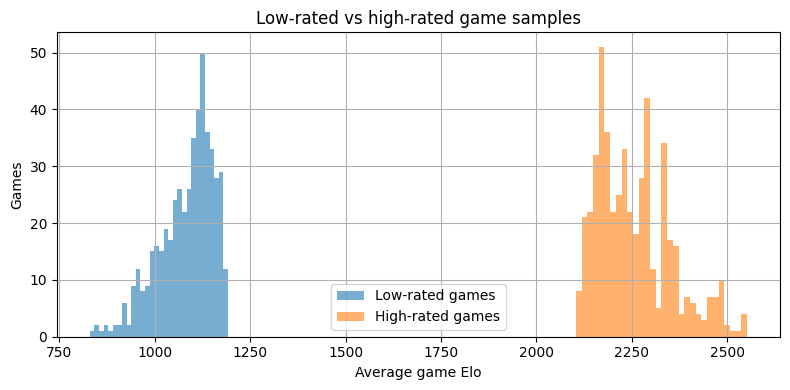

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

df_bvt.loc[df_bvt["rating_class"].eq(0), "avg_elo"].hist(
  bins=30,
  alpha=0.6,
  ax=ax,
  label="Low-rated games",
)

df_bvt.loc[df_bvt["rating_class"].eq(1), "avg_elo"].hist(
  bins=30,
  alpha=0.6,
  ax=ax,
  label="High-rated games",
)

ax.set_xlabel("Average game Elo")
ax.set_ylabel("Games")
ax.set_title("Low-rated vs high-rated game samples")
ax.legend()
plt.tight_layout()
plt.show()

Important note: the two groups will not literally be Gaussian just because 
we cut at <1200 and >2100. They are clean separated rating bands, which is more 
important for this first experiment. If you later want “approximately Gaussian” 
distributions, you can sample from windows like 900–1200 and 2100–2400, 
or sample around target means.

In [50]:
# Robust move parser
def coerce_moves_uci(value):
  """Return a Python list of UCI moves from several possible storage formats."""
  if isinstance(value, list):
    return value

  if isinstance(value, tuple):
    return list(value)

  if value is None:
    return []

  if isinstance(value, float) and np.isnan(value):
    return []

  if isinstance(value, str):
    text = value.strip()

    if text.startswith("[") and text.endswith("]"):
      try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
          return parsed
      except Exception:
        pass

    # Fallback for space-separated UCI strings.
    return text.split()

  return []

In [51]:
# Stockfish evaluation helpers
def cp_score_from_info(info, pov_color):
  """Convert python-chess engine info to a centipawn score from pov_color."""
  score = info["score"].pov(pov_color)
  return score.score(mate_score=MATE_SCORE)


def phase_from_ply(ply):
  """Simple chess phase label based on ply number."""
  if ply <= 16:
    return "opening"
  elif ply <= 40:
    return "middlegame"
  else:
    return "late"


def analyze_game_with_stockfish(row, engine):
  """
  Analyze one game and return one row per evaluated ply.

  Each row describes the move actually played, the Stockfish evaluation
  before the move, the evaluation after the move, and the centipawn loss.
  """
  game_id = row["game_id"]
  moves_uci = coerce_moves_uci(row["moves_uci"])

  board = chess.Board()
  records = []

  max_plies = min(len(moves_uci), ENGINE_MAX_PLIES)

  for ply_idx, move_uci in enumerate(moves_uci[:max_plies], start=1):
    try:
      move = chess.Move.from_uci(move_uci)
    except ValueError:
      break

    if move not in board.legal_moves:
      break

    mover = board.turn
    mover_name = "white" if mover == chess.WHITE else "black"

    piece = board.piece_at(move.from_square)
    piece_symbol = piece.symbol().lower() if piece is not None else "unknown"

    is_capture = board.is_capture(move)
    is_castling = board.is_castling(move)
    is_promotion = move.promotion is not None

    # SAN must be computed before pushing the move.
    try:
      san = board.san(move)
    except Exception:
      san = None

    # Evaluation before the move: approximately the best achievable eval.
    info_before = engine.analyse(
      board,
      chess.engine.Limit(depth=ENGINE_DEPTH),
    )

    eval_before_cp = cp_score_from_info(info_before, mover)

    board.push(move)

    is_check = board.is_check()

    # Evaluation after the actual played move.
    info_after = engine.analyse(
      board,
      chess.engine.Limit(depth=ENGINE_DEPTH),
    )

    eval_after_cp = cp_score_from_info(info_after, mover)

    cp_loss = eval_before_cp - eval_after_cp

    # Numerical safety.
    cp_loss = max(0, cp_loss)
    cp_loss_clipped = min(cp_loss, CP_LOSS_CLIP)

    records.append(
      {
        "game_id": game_id,
        "ply": ply_idx,
        "fullmove_number": (ply_idx + 1) // 2,
        "mover": mover_name,
        "move_uci": move_uci,
        "move_san": san,
        "piece": piece_symbol,
        "phase": phase_from_ply(ply_idx),
        "is_capture": int(is_capture),
        "is_castling": int(is_castling),
        "is_promotion": int(is_promotion),
        "is_check": int(is_check),
        "eval_before_cp": eval_before_cp,
        "eval_after_cp": eval_after_cp,
        "cp_loss": cp_loss,
        "cp_loss_clipped": cp_loss_clipped,
        "is_inaccuracy": int(cp_loss >= INACCURACY_CP),
        "is_mistake": int(cp_loss >= MISTAKE_CP),
        "is_blunder": int(cp_loss >= BLUNDER_CP),
      }
    )

  return records

## Run Stockfish analysis (expensive)

In [52]:
engine_eval_path = PROCESSED_DIR / (
  f"bottom_vs_top_stockfish_"
  f"{len(df_bvt)}games_"
  f"{ENGINE_MAX_PLIES}plies_"
  f"depth{ENGINE_DEPTH}.parquet"
)

if engine_eval_path.exists():
  df_moves_eval = pd.read_parquet(engine_eval_path)
  print(f"Loaded cached Stockfish evaluations: {engine_eval_path}")

else:
  if STOCKFISH_PATH is None:
    raise ValueError(
      "Could not find Stockfish. Set STOCKFISH_PATH manually in the config cell."
    )

  all_records = []

  with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
    try:
      engine.configure(
        {
          "Threads": ENGINE_THREADS,
          "Hash": ENGINE_HASH_MB,
        }
      )
    except chess.engine.EngineError:
      print("Could not configure Threads/Hash. Continuing with defaults.")

    for _, row in tqdm(
      df_bvt.iterrows(),
      total=len(df_bvt),
      desc="Analyzing games with Stockfish",
    ):
      records = analyze_game_with_stockfish(row, engine)
      all_records.extend(records)

  df_moves_eval = pd.DataFrame(all_records)
  df_moves_eval.to_parquet(engine_eval_path, index=False)
  print(f"Wrote: {engine_eval_path}")

print(df_moves_eval.shape)
df_moves_eval.head()

Analyzing games with Stockfish:   0%|          | 0/1000 [00:00<?, ?it/s]

Wrote: data/processed/bottom_vs_top_stockfish_1000games_40plies_depth8.parquet
(38539, 19)


,game_id,ply,fullmove_number,mover,move_uci,move_san,piece,phase,is_capture,is_castling,is_promotion,is_check,eval_before_cp,eval_after_cp,cp_loss,cp_loss_clipped,is_inaccuracy,is_mistake,is_blunder
0,0,1,1,white,d2d4,d4,p,opening,0,0,0,0,36,44,0,0,0,0,0
1,0,2,1,black,d7d5,d5,p,opening,0,0,0,0,-40,-40,0,0,0,0,0
2,0,3,2,white,c2c4,c4,p,opening,0,0,0,0,27,46,0,0,0,0,0
3,0,4,2,black,e7e6,e6,p,opening,0,0,0,0,-47,-37,0,0,0,0,0
4,0,5,3,white,b1c3,Nc3,n,opening,0,0,0,0,27,28,0,0,0,0,0


In [53]:
# Inspect
display(df_moves_eval.describe())

print("Move phases:")
display(df_moves_eval["phase"].value_counts().to_frame("count"))

print("Pieces moved:")
display(df_moves_eval["piece"].value_counts().to_frame("count"))

print("Centipawn loss summary:")
display(
  df_moves_eval[
    [
      "cp_loss",
      "cp_loss_clipped",
      "is_inaccuracy",
      "is_mistake",
      "is_blunder",
    ]
  ].describe()
)

,game_id,ply,fullmove_number,is_capture,is_castling,is_promotion,is_check,eval_before_cp,eval_after_cp,cp_loss,cp_loss_clipped,is_inaccuracy,is_mistake,is_blunder
count,38539.000000,38539.000000,38539.000000,38539.000000,38539.000000,38539.00000,38539.000000,38539.000000,38539.000000,38539.00000,38539.000000,38539.000000,38539.000000,38539.000000
mean,500.522613,19.975869,10.238486,0.234360,0.035808,0.00013,0.042554,280.905576,-203.089546,494.25229,61.676639,0.303355,0.160694,0.035029
std,288.926857,11.402452,5.696315,0.423604,0.185813,0.01139,0.201853,7038.549475,8167.553764,6609.87340,161.932962,0.459713,0.367254,0.183857
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,-99999.000000,-99999.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,250.000000,10.000000,5.000000,0.000000,0.000000,0.00000,0.000000,-54.000000,-100.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,501.000000,20.000000,10.000000,0.000000,0.000000,0.00000,0.000000,22.000000,-17.000000,17.00000,17.000000,0.000000,0.000000,0.000000
75%,752.000000,30.000000,15.000000,0.000000,0.000000,0.00000,0.000000,93.000000,58.000000,63.50000,63.500000,1.000000,0.000000,0.000000
max,999.000000,40.000000,20.000000,1.000000,1.000000,1.00000,1.000000,99999.000000,100000.000000,100732.00000,2000.000000,1.000000,1.000000,1.000000


Move phases:


,count
phase,
middlegame,22539
opening,16000


Pieces moved:


,count
piece,
p,13257
n,8635
b,7162
q,4593
r,2452
k,2440


Centipawn loss summary:


,cp_loss,cp_loss_clipped,is_inaccuracy,is_mistake,is_blunder
count,38539.00000,38539.000000,38539.000000,38539.000000,38539.000000
mean,494.25229,61.676639,0.303355,0.160694,0.035029
std,6609.87340,161.932962,0.459713,0.367254,0.183857
min,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000
50%,17.00000,17.000000,0.000000,0.000000,0.000000
75%,63.50000,63.500000,1.000000,0.000000,0.000000
max,100732.00000,2000.000000,1.000000,1.000000,1.000000


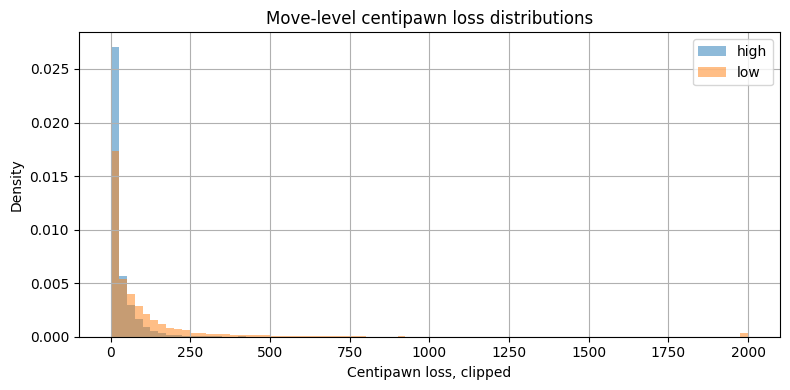

In [54]:
df_moves_with_label = df_moves_eval.merge(
  df_bvt[
    [
      "game_id",
      "rating_class",
      "rating_class_name",
      "white_elo",
      "black_elo",
      "avg_elo",
    ]
  ],
  on="game_id",
  how="left",
)

fig, ax = plt.subplots(figsize=(8, 4))

for class_name, group in df_moves_with_label.groupby("rating_class_name"):
  group["cp_loss_clipped"].hist(
    bins=80,
    alpha=0.5,
    density=True,
    ax=ax,
    label=class_name,
  )

ax.set_xlabel("Centipawn loss, clipped")
ax.set_ylabel("Density")
ax.set_title("Move-level centipawn loss distributions")
ax.legend()
plt.tight_layout()
plt.show()

In [55]:
def make_game_level_stockfish_features(df_moves_eval):
  """Aggregate move-level Stockfish data into one feature row per game."""

  df = df_moves_eval.copy()

  # Overall game summaries.
  overall = df.groupby("game_id").agg(
    n_eval_plies=("ply", "count"),

    cp_loss_mean=("cp_loss_clipped", "mean"),
    cp_loss_std=("cp_loss_clipped", "std"),
    cp_loss_median=("cp_loss_clipped", "median"),
    cp_loss_p75=("cp_loss_clipped", lambda x: np.percentile(x, 75)),
    cp_loss_p90=("cp_loss_clipped", lambda x: np.percentile(x, 90)),
    cp_loss_max=("cp_loss_clipped", "max"),

    eval_before_mean=("eval_before_cp", "mean"),
    eval_before_std=("eval_before_cp", "std"),
    eval_after_mean=("eval_after_cp", "mean"),
    eval_after_std=("eval_after_cp", "std"),

    inaccuracy_rate=("is_inaccuracy", "mean"),
    mistake_rate=("is_mistake", "mean"),
    blunder_rate=("is_blunder", "mean"),

    capture_rate=("is_capture", "mean"),
    check_rate=("is_check", "mean"),
    castling_rate=("is_castling", "mean"),
    promotion_rate=("is_promotion", "mean"),
  )

  # Phase-specific centipawn loss summaries.
  phase_mean = df.pivot_table(
    index="game_id",
    columns="phase",
    values="cp_loss_clipped",
    aggfunc="mean",
  )

  phase_mean.columns = [
    f"cp_loss_mean_{col}" for col in phase_mean.columns
  ]

  phase_blunder = df.pivot_table(
    index="game_id",
    columns="phase",
    values="is_blunder",
    aggfunc="mean",
  )

  phase_blunder.columns = [
    f"blunder_rate_{col}" for col in phase_blunder.columns
  ]

  # Side-specific summaries.
  side_loss = df.pivot_table(
    index="game_id",
    columns="mover",
    values="cp_loss_clipped",
    aggfunc="mean",
  )

  side_loss.columns = [
    f"cp_loss_mean_{col}" for col in side_loss.columns
  ]

  side_blunder = df.pivot_table(
    index="game_id",
    columns="mover",
    values="is_blunder",
    aggfunc="mean",
  )

  side_blunder.columns = [
    f"blunder_rate_{col}" for col in side_blunder.columns
  ]

  # Piece-specific average losses.
  piece_loss = df.pivot_table(
    index="game_id",
    columns="piece",
    values="cp_loss_clipped",
    aggfunc="mean",
  )

  piece_loss.columns = [
    f"cp_loss_mean_piece_{col}" for col in piece_loss.columns
  ]

  features = pd.concat(
    [
      overall,
      phase_mean,
      phase_blunder,
      side_loss,
      side_blunder,
      piece_loss,
    ],
    axis=1,
  )

  features = features.replace([np.inf, -np.inf], np.nan)
  features = features.fillna(0)

  return features.reset_index()

In [56]:
df_sf_features = make_game_level_stockfish_features(df_moves_eval)

print(df_sf_features.shape)
df_sf_features.head()

(1000, 33)


,game_id,n_eval_plies,cp_loss_mean,cp_loss_std,cp_loss_median,cp_loss_p75,cp_loss_p90,cp_loss_max,eval_before_mean,eval_before_std,eval_after_mean,eval_after_std,inaccuracy_rate,mistake_rate,blunder_rate,capture_rate,check_rate,castling_rate,promotion_rate,cp_loss_mean_middlegame,cp_loss_mean_opening,blunder_rate_middlegame,blunder_rate_opening,cp_loss_mean_black,cp_loss_mean_white,blunder_rate_black,blunder_rate_white,cp_loss_mean_piece_b,cp_loss_mean_piece_k,cp_loss_mean_piece_n,cp_loss_mean_piece_p,cp_loss_mean_piece_q,cp_loss_mean_piece_r
0,0,40,7.100000,10.738858,2.0,8.00,25.3,41,2.350000,31.735728,-2.775000,32.746491,0.000000,0.000000,0.000000,0.150000,0.000000,0.050000,0.0,8.375000,5.1875,0.000000,0.0000,7.000000,7.200000,0.000000,0.000000,5.444444,12.50,6.888889,5.428571,17.000000,7.000000
1,1,40,14.525000,18.302287,7.5,25.25,40.0,68,6.825000,53.040327,-5.875000,52.959194,0.075000,0.000000,0.000000,0.200000,0.050000,0.050000,0.0,19.041667,7.7500,0.000000,0.0000,13.950000,15.100000,0.000000,0.000000,9.833333,0.00,13.777778,16.875000,23.250000,11.666667
2,2,40,29.775000,51.831822,8.5,27.75,94.8,233,12.250000,108.059753,-14.325000,112.037170,0.150000,0.100000,0.000000,0.250000,0.025000,0.050000,0.0,43.791667,8.7500,0.000000,0.0000,34.050000,25.500000,0.000000,0.000000,47.444444,10.75,17.000000,10.181818,124.666667,21.666667
3,3,40,25.975000,45.139946,3.0,40.75,79.8,213,20.300000,167.507857,-3.600000,175.570981,0.225000,0.100000,0.000000,0.275000,0.025000,0.050000,0.0,33.666667,14.4375,0.000000,0.0000,19.600000,32.350000,0.000000,0.000000,39.500000,30.50,3.375000,16.100000,31.400000,47.600000
4,4,35,86.428571,183.382802,25.0,67.00,241.0,809,51.085714,321.848921,-31.542857,350.485742,0.285714,0.142857,0.114286,0.285714,0.057143,0.028571,0.0,117.210526,49.8750,0.157895,0.0625,110.058824,64.111111,0.117647,0.111111,197.500000,6.00,70.545455,15.562500,809.000000,0.000000


In [57]:
df_model = df_bvt[
  [
    "game_id",
    "rating_class",
    "rating_class_name",
    "num_plies",
    "result",
    "eco",
    "time_control",
  ]
].merge(
  df_sf_features,
  on="game_id",
  how="inner",
)

print(df_model.shape)
df_model.head()

(1000, 39)


,game_id,rating_class,rating_class_name,num_plies,result,eco,time_control,n_eval_plies,cp_loss_mean,cp_loss_std,cp_loss_median,cp_loss_p75,cp_loss_p90,cp_loss_max,eval_before_mean,eval_before_std,eval_after_mean,eval_after_std,inaccuracy_rate,mistake_rate,blunder_rate,capture_rate,check_rate,castling_rate,promotion_rate,cp_loss_mean_middlegame,cp_loss_mean_opening,blunder_rate_middlegame,blunder_rate_opening,cp_loss_mean_black,cp_loss_mean_white,blunder_rate_black,blunder_rate_white,cp_loss_mean_piece_b,cp_loss_mean_piece_k,cp_loss_mean_piece_n,cp_loss_mean_piece_p,cp_loss_mean_piece_q,cp_loss_mean_piece_r
0,0,1,high,110,0-1,D53,180+0,40,7.100000,10.738858,2.0,8.00,25.3,41,2.350000,31.735728,-2.775000,32.746491,0.000000,0.000000,0.000000,0.150000,0.000000,0.050000,0.0,8.375000,5.1875,0.000000,0.0000,7.000000,7.200000,0.000000,0.000000,5.444444,12.50,6.888889,5.428571,17.000000,7.000000
1,1,1,high,69,1-0,E00,300+0,40,14.525000,18.302287,7.5,25.25,40.0,68,6.825000,53.040327,-5.875000,52.959194,0.075000,0.000000,0.000000,0.200000,0.050000,0.050000,0.0,19.041667,7.7500,0.000000,0.0000,13.950000,15.100000,0.000000,0.000000,9.833333,0.00,13.777778,16.875000,23.250000,11.666667
2,2,1,high,53,1-0,B59,300+0,40,29.775000,51.831822,8.5,27.75,94.8,233,12.250000,108.059753,-14.325000,112.037170,0.150000,0.100000,0.000000,0.250000,0.025000,0.050000,0.0,43.791667,8.7500,0.000000,0.0000,34.050000,25.500000,0.000000,0.000000,47.444444,10.75,17.000000,10.181818,124.666667,21.666667
3,3,1,high,64,0-1,A01,180+0,40,25.975000,45.139946,3.0,40.75,79.8,213,20.300000,167.507857,-3.600000,175.570981,0.225000,0.100000,0.000000,0.275000,0.025000,0.050000,0.0,33.666667,14.4375,0.000000,0.0000,19.600000,32.350000,0.000000,0.000000,39.500000,30.50,3.375000,16.100000,31.400000,47.600000
4,4,0,low,35,1-0,B01,300+0,35,86.428571,183.382802,25.0,67.00,241.0,809,51.085714,321.848921,-31.542857,350.485742,0.285714,0.142857,0.114286,0.285714,0.057143,0.028571,0.0,117.210526,49.8750,0.157895,0.0625,110.058824,64.111111,0.117647,0.111111,197.500000,6.00,70.545455,15.562500,809.000000,0.000000


In [62]:
# Numeric features from Stockfish plus basic non-rating metadata.
numeric_cols = [
  col for col in df_model.columns
  if col not in [
    "game_id",
    "rating_class",
    "rating_class_name",
    "result",
    "eco",
    "time_control",
  ]
]

X_num = df_model[numeric_cols].copy()

# Optional categorical one-hot features.
# These are not move-token one-hot features yet.
# They encode metadata such as result, ECO code, and time control.
cat_cols = [
  "result",
  "eco",
  "time_control",
]

X_cat = pd.get_dummies(
  df_model[cat_cols].astype("string"),
  columns=cat_cols,
  dummy_na=True,
)

X = pd.concat([X_num, X_cat], axis=1)
y = df_model["rating_class"].astype(int)

print("Feature matrix:", X.shape)
print("Target distribution:")
display(y.value_counts().to_frame("count"))

X_num = df_model[numeric_cols].copy()

X_cat = pd.get_dummies(
  df_model[cat_cols].astype("string"),
  dummy_na=True,
)

X = pd.concat([X_num, X_cat], axis=1)
X = make_xgb_safe(X)

y = df_model["rating_class"].astype(int)

print(X.shape)
display(y.value_counts().to_frame("count"))

Feature matrix: (1000, 271)
Target distribution:


,count
rating_class,
1,500
0,500


AttributeError: module 'pandas.io.parsers' has no attribute 'ParserBase'

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.25,
  random_state=RANDOM_STATE,
  stratify=y,
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

display(y_train.value_counts().to_frame("train_count"))
display(y_test.value_counts().to_frame("test_count"))

Train: (750, 271)
Test:  (250, 271)


,train_count
rating_class,
1,375
0,375


,test_count
rating_class,
0,125
1,125


In [60]:
bdt = XGBClassifier(
  n_estimators=500,
  max_depth=3,
  learning_rate=0.03,
  subsample=0.8,
  colsample_bytree=0.8,
  min_child_weight=3,
  reg_lambda=2.0,
  objective="binary:logistic",
  eval_metric="logloss",
  random_state=RANDOM_STATE,
  n_jobs=-1,
)

bdt.fit(X_train, y_train)

y_pred = bdt.predict(X_test)
y_proba = bdt.predict_proba(X_test)[:, 1]

print("Accuracy:          ", accuracy_score(y_test, y_pred))
print("Balanced accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:           ", roc_auc_score(y_test, y_proba))

print()
print(classification_report(
  y_test,
  y_pred,
  target_names=["low", "high"],
))

ValueError: feature_names must be string, and may not contain [, ] or <